# 制造业 AI 演示 笔记本
## 不依赖 MES，如何从原始设备日志中提取“良率相关”洞察

### 业务背景（前因）
在很多工厂里，设备每天都会产生大量日志（上百列参数、秒级/分钟级时间序列），但现场团队经常遇到同一个问题：

- 数据很多，但难以快速回答“最近良率波动可能和哪些过程变量有关”。
- 完整 MES 项目虽然功能强，但建设周期长、跨系统打通复杂、导入成本高。
- 在没有良率标签（如 批次级良率）的情况下，传统方法容易卡住。

### 本 笔记本 的目标（后果/价值）
本演示给客户一个“可快速落地”的路径：
1. 直接读取设备导出的 Excel / CSV 日志；
2. 构建一个干净的过程特征层；
3. 用轻量 AI（异常检测）找出“可疑工况时段”；
4. 对比正常 vs 异常段，近似推断潜在良率影响因子。

> **给客户的核心价值**：即使没有 MES、没有良率标签，也可以在几天内做出可行动的过程洞察。

In [7]:
import re
from pathlib import Path
import openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# 中文显示名映射：仅用于图表和展示，不修改原始字段名
column_display_map = {
    "running speed": "运行速度",
    "speed": "速度",
    "line speed": "产线速度",
    "ag deplating ph": "脱银槽pH值",
    "ph": "pH值",
    "pressure": "压力",
    "temperature": "温度",
    "temp": "温度",
    "flow": "流量",
    "current": "电流",
    "voltage": "电压",
    "torque": "扭矩",
    "vibration": "振动",
    "rpm": "转速",
    "speed_diff": "速度变化强度",
    "ph_range": "pH波动范围",
    "pressure_variation": "压力波动",
    "anomaly_score": "异常分数",
    "anomaly_flag": "异常标记",
    "normal_mean": "正常段均值",
    "abnormal_mean": "异常段均值",
    "abs_diff": "绝对差异",
    "pct_diff_vs_normal": "相对正常段变化(%)",
}

def cn_label(col_name):
    """返回中文展示名；找不到时回退原列名。"""
    return column_display_map.get(str(col_name).strip().lower(), col_name)


In [8]:
# 中文字体初始化（用于 Matplotlib 图表）
import matplotlib as mpl
from matplotlib import font_manager
import warnings

# 可选：隐藏缺字形告警，避免演示时出现红色 warning
warnings.filterwarnings("ignore", category=UserWarning, message=r"Glyph.*missing from font")

# 按优先级尝试字体：PingFang（macOS）-> STHeiti -> Hiragino Sans GB -> Arial Unicode
font_candidates = [
    ("PingFang SC", [
        "/System/Library/Fonts/PingFang.ttc",
    ]),
    ("STHeiti", [
        "/System/Library/Fonts/STHeiti Light.ttc",
        "/System/Library/Fonts/STHeiti Medium.ttc",
    ]),
    ("Hiragino Sans GB", [
        "/System/Library/Fonts/Hiragino Sans GB.ttc",
    ]),
    ("Arial Unicode MS", [
        "/Library/Fonts/Arial Unicode.ttf",
        "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
        "/System/Library/Fonts/Supplemental/Arial Unicode MS.ttf",
    ]),
]

selected_font = None
for font_name, font_paths in font_candidates:
    for font_path in font_paths:
        p = Path(font_path)
        if p.exists():
            try:
                font_manager.fontManager.addfont(str(p))
                selected_font = font_name
                break
            except Exception as e:
                print(f"加载字体失败 {font_path}: {e}")
    if selected_font:
        break

if selected_font:
    mpl.rcParams["font.family"] = selected_font
    mpl.rcParams["font.sans-serif"] = [selected_font]
    mpl.rcParams["axes.unicode_minus"] = False
    print(f"Matplotlib 中文字体已设置为: {selected_font}")
else:
    print("未找到可用中文字体（PingFang/STHeiti/Hiragino Sans GB/Arial Unicode）。图表可能出现中文缺字。")



Matplotlib 中文字体已设置为: STHeiti


## 1) 数据加载
此步骤的关键点：
- 兼容 Excel / CSV；
- 尽量自动识别时间列并排序；
- 先建立“可复用的数据读取函数”，后续项目可直接复用。

**为什么这样做？**
现场数据常来自不同设备厂商，字段命名不统一。先把加载层做稳，后续分析才不会反复返工。


In [9]:
def load_data(file_path, time_col_candidates=None):
    # 中文说明：统一入口读取设备日志，支持 Excel/CSV。
    # 前因：客户现场常见多种格式导出。
    # 后果：统一函数后，后续清洗/建模代码不需要改动。
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"文件不存在：{file_path}")

    if time_col_candidates is None:
        # 中文说明：常见时间列候选名（可按客户现场再扩展）
        time_col_candidates = ["timestamp", "time", "datetime", "date_time", "record_time", "log_time"]

    if file_path.suffix.lower() in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    elif file_path.suffix.lower() == ".csv":
        df = pd.read_csv(file_path)
    else:
        raise ValueError("不支持的文件类型，请使用 Excel（.xlsx/.xls）或 CSV。")

    # 中文说明：尝试自动匹配时间列，并做时间解析+排序
    normalized_map = {c.lower().strip(): c for c in df.columns}
    selected_time_col = None
    for cand in time_col_candidates:
        if cand in normalized_map:
            selected_time_col = normalized_map[cand]
            break

    if selected_time_col is not None:
        df[selected_time_col] = pd.to_datetime(df[selected_time_col], errors="coerce")
        df = df.sort_values(selected_time_col).reset_index(drop=True)
        print(f"已识别时间列：{selected_time_col}")
    else:
        print("未在候选字段中识别到时间列。")

    print(f"数据规模：{df.shape[0]:,} 行 × {df.shape[1]:,} 列")
    return df

In [10]:
# --- 中文说明：请改成客户现场日志文件路径 ---
# 示例：data_path = "data/equipment_log.xlsx"
# 为方便快速演示，这里默认读取仓库内的样例文件。
from pathlib import Path

data_path = Path("../data/equipment_log.xlsx").resolve()
print("当前读取文件：", data_path)
df_raw = load_data(data_path)

# 展示原始数据前几行与字段统计，帮助工程师快速建立数据直觉
display(df_raw.head(3))
display(df_raw.describe(include="all").transpose().head(10))


当前读取文件： /Users/jiaoguodong/Desktop/myApp/Industry_AIDemo/data/equipment_log.xlsx
已识别时间列：Time
数据规模：1,496 行 × 173 列


,Time,L1 Mode,L1 Product Name,L1 Lot ID,L1 Tool ID,L1 Electrode ID,L1 Standard Speed,L1 Target Speed,L1 Running Speed,L1 Pump(1) Speed(L),L1 Pump(1) Speed(H),L1 Pump(2) Speed(L),L1 Pump(2) Speed(H),L1 Length,L1 ED(1) OnOff,L1 ED(1) Current,L1 ED(1) Voltage,L1 ED(2) OnOff,L1 ED(2) Current,L1 ED(2) Voltage,L1 Ag Strike(1) OnOff,L1 Ag Strike(1) Current,L1 Ag Strike(1) Voltage,L1 Ag Strike(2) OnOff,L1 Ag Strike(2) Current,L1 Ag Strike(2) Voltage,L1 Strike Current,L1 Strike Voltage,L1 Spot(1) OnOff,L1 Spot(1) Current,L1 Spot(1) Current OnTime,L1 Spot(1) Current OffTime,L1 Spot(1) Voltage,L1 Spot(2) OnOff,L1 Spot(2) Current,L1 Spot(2) Current OnTime,L1 Spot(2) Current OffTime,L1 Spot(2) Voltage,L1 Ag plating(1) OnOff,L1 Ag plating(1) Current,L1 Ag plating(1) Voltage,L1 Ag plating(2) OnOff,L1 Ag plating(2) Current,L1 Ag Deplating(2) Voltage,L1 Ag plating(3) OnOff,L1 Ag plating(3) Current,L1 Ag plating(3) Voltage,L1 Pre-Acid Rinse TC,L1 Post-Acid Rinse TC,L1 Anti-Tarnish TC,L1 Anti-EO TC,L1 Oven(1) TC,L1 Oven(2) TC,L1 air Flow,L1 RO(1) Flow,L1 DI(1) Flow,L1 AgSpot(1) Flow,L1 AgSpot(2) Flow,L1 Air(Oilfree) Flow,L1 DI(2) Flow,L1_PostDip Cond,L1_EO Cond,L1 Air Pressure,L1 RO(1) Pressure,L1 DI(1) Pressure,L1 Air(Oilfree) Pressure,L1 DI(1) Pressure.1,L2 Mode,L2 Product Name,L2 Lot ID,L2 Tool ID,L2 Electrode ID,L2 Standard Speed,L2 Target Speed,L2 Running Speed,L2 Pump(1) Speed(L),L2 Pump(1) Speed(H),L2 Pump(2) Speed(L),L2 Pump(2) Speed(H),L2 Length,L2 ED(1) OnOff,L2 ED(1) Current,L2 ED(1) Voltage,L2 ED(2) OnOff,L2 ED(2) Current,L2 ED(2) Voltage,L2 Ag Strike(1) OnOff,L2 Ag Strike(1) Current,L2 Ag Strike(1) Voltage,L2 Ag Strike(2) OnOff,L2 Ag Strike(2) Current,L2 Ag Strike(2) Voltage,L2 Strike OnOff,L2 Strike Current,L2 Strike Voltage,L2 Spot(1) OnOff,L2 Spot(1) Current,L2 Spot(1) Current OnTime,L2 Spot(1) Current OffTime,L2 Spot(1) Voltage,L2 Spot(2) OnOff,L2 Spot(2) Current,L2 Spot(2) Current OnTime,L2 Spot(2) Current OffTime,L2 Spot(2) Voltage,L2 Ag Deplating(1) OnOff,L2 Ag plating(1) Current,L2 Ag plating(1) Voltage,L2 Ag plating(2) OnOff,L2 Ag plating(2) Current,L2 Ag plating(2) Voltage,L2 Ag plating(3) OnOff,L2 Ag plating(3) Current,L2 Ag plating(3) Voltage,L2 Pre-Acid Rinse TC,L2 Post-Acid Rinse TC,L2 Anti-Tarnish TC,L2 Anti-EO TC,L2 Oven(1) TC,L2 Oven(1) TC.1,L2 Oven(2) TC,L2 air Flow,L2 RO(1) Flow,L2 DI(1) Flow,L2 AgSpot(1) Flow,L2 AgSpot(2) Flow,L2 Air(Oilfree) Flow,L2 DI(2) Flow,L2_PostDip Cond,L2_EBO Cond,L2 Air Pressure,L2 RO(1) Pressure,L2 DI(1) Pressure,L2 Air(Oilfree) Pressure,L2 DI(1) Pressure.1,Ag Deplating(1&2)LT OnOff,Ag Deplating(1&2)LT Current,Ag Deplating(1&2)LT Voltage,Ag Deplating(3)LT OnOff,Ag Deplating(3)LT Current,Ag Deplating(3)LT Voltage,ED(1) TC,ED(2) TC,Cu Strike TC,Ag Strike TC,Ag Spot TC,Ag Recycle TC,Hot RDI(1) TC,Ag Deplating(1&2) TC,Ag Deplating(3) TC,Ultrasonic RDI TC,Hot RDI(2) TC,M4AgStrike(1),M4DropCount,M5AgSpot,M5DropCount,RO(1) Flow,DI(1) Flow,Ag Deplating(1) Flow,Ag Deplating(3) Flow,DI(2) Flow,Ag Deplating(1&2) Beau,Ag Deplating(3) Beau,RDI(1) Cond,Cu Strike Level,Ag Strike Level,Ag Spot Level,Ag Spot pH,Ag Deplating(1&2) pH,Ag Deplating(3) pH,RO(1) Pressure,DI(1) Pressure,DI(1) Pressure.1
0,NaT,L1:Motion Only,1,NaN,NaN,NaN,0,2.2,0.0,30,85,0,0,57363.636364,Off,0,0.0,Off,0,0.0,Off,0.0,0.0,Off,0,0.0,0.0,0.0,Off,0.0,60,10,0.0,Off,0,0,0,0,Off,0.0,0.0,Off,0.0,0.0,Off,0.0,0.0,30.2,29.8,16.7,24.5,144.7,144.9,0.0,0.0,0.0,0.0018,0.0018,0.0,0.0,54.639622,15.679215,8.045488,1.098119,1.376667,1.160999,1.173865,L2:Motion Only,YC24-UTN241100108L(BNQNS80036-1).uyu,NaN,NaN,NaN,3,3,0.3,0,0,30,80,55818.181818,Off,0.0,0.0,Off,0.0,0.0,Off,0,0.0,Off,0.0,0.0,Off,0.0,0.0,Off,0,60,10,0,Off,0.0,40,10,0.0,Off,0.0,0.0,Off,0.0,0.0,Off,0.0,0.0,30.2,29.6,29.6,24.7,143.6,143.6,144.9,0.0,0.0,0.0,0.0018,0.0018,0.0,0.0,44.419739,29.534798,3.138171,1.178638,1.408929,6.000685,6.005870,Off,0.0,0.0,Off,0.0,0.0,59.9,60.3,64.7,27.9,68.0,45.0,45.4,12.0,11.8,45.0,45.4,58844.8775,0,26564.983405,0,0.0,0.0,29.454693,0.0,0.0,5.889424,2.23724

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Time,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
L1 Mode,1496,2,L1:Motion Only,1418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1 Product Name,1496.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
L1 Lot ID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1 Tool ID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1 Electrode ID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1 Standard Speed,1496.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
L1 Target Speed,1496.0,NaN,NaN,NaN,2.2,2.2,2.2,2.2,2.2,2.2,0.0
L1 Running Speed,1496.0,NaN,NaN,NaN,0.232353,0.0,0.0,0.0,0.0,2.3,0.657803
L1 Pump(1) Speed(L),1496.0,NaN,NaN,NaN,30.0,30.0,30.0,30.0,30.0,30.0,0.0


## 1.5) 设备日志标准化处理（新增）
在数据加载后、异常检测前新增标准化模块，自动识别 Time / 线体字段 / 公共字段，并输出标准化结果。


In [11]:
# ============================================================
# 设备日志标准化处理 Cell
# 功能：
# - 宽表设备日志 -> Line_Snapshot / Common_Snapshot / Measurement_Long
# - 自动识别 L1/L2/L3...
# - 自动识别公共设备参数
# - 自动保留重复字段
# - 自动输出标准化 Excel（data 目录）
# - 输入文件未变化时跳过重复生成
# ============================================================

import re
import json
import itertools
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from IPython.display import display, Markdown


# -----------------------------
# 0. 输入输出文件设置
# -----------------------------
INPUT_FILE = Path(str(data_path)) if "data_path" in globals() else Path("Y2026M04D20data V1.0.xlsx")
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = OUTPUT_DIR / "processed_equipment_log_standardized.xlsx"
CACHE_META_FILE = OUTPUT_DIR / ".processed_equipment_log_standardized.meta.json"


def build_input_signature(file_path):
    file_path = Path(file_path)
    stat = file_path.stat()
    return {
        "path": str(file_path.resolve()),
        "size": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def should_rebuild(input_file, output_file, cache_meta_file):
    input_file = Path(input_file)
    output_file = Path(output_file)
    cache_meta_file = Path(cache_meta_file)

    if not input_file.exists():
        raise FileNotFoundError(f"找不到输入文件：{input_file.resolve()}")

    if not output_file.exists() or not cache_meta_file.exists():
        return True, build_input_signature(input_file)

    try:
        old_meta = json.loads(cache_meta_file.read_text(encoding="utf-8"))
    except Exception:
        return True, build_input_signature(input_file)

    new_signature = build_input_signature(input_file)
    old_signature = old_meta.get("input_signature", {})
    return old_signature != new_signature, new_signature


def save_cache_meta(cache_meta_file, input_signature):
    cache_meta_file = Path(cache_meta_file)
    payload = {
        "input_signature": input_signature,
        "output_file": str(Path(OUTPUT_FILE).resolve()),
    }
    cache_meta_file.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def load_standardized_excel(output_file):
    output_file = Path(output_file)
    sheets = pd.read_excel(output_file, sheet_name=None)

    required = [
        "Raw_Data", "Field_Map", "Field_Diagnostics",
        "Duplicate_Value_Check", "Line_Snapshot", "Common_Snapshot", "Measurement_Long",
    ]
    missing = [s for s in required if s not in sheets]
    if missing:
        raise ValueError(f"输出文件缺少必要 Sheet: {missing}")

    return {
        "raw_data": sheets["Raw_Data"],
        "field_map": sheets["Field_Map"],
        "field_diagnostics": sheets["Field_Diagnostics"],
        "duplicate_value_check": sheets["Duplicate_Value_Check"],
        "line_snapshot": sheets["Line_Snapshot"],
        "common_snapshot": sheets["Common_Snapshot"],
        "measurement_long": sheets["Measurement_Long"],
    }


def read_excel_keep_duplicate_headers(file_path):
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"找不到输入文件：{file_path.resolve()}")

    df_raw_all = pd.read_excel(file_path, header=None)
    if df_raw_all.empty:
        raise ValueError("输入 Excel 为空，无法解析。")

    header = df_raw_all.iloc[0].fillna("").astype(str).str.strip().tolist()
    data = df_raw_all.iloc[1:].reset_index(drop=True).copy()

    counts = defaultdict(int)
    unique_cols = []
    meta_rows = []
    for idx, col in enumerate(header, start=1):
        original_name = col if col else f"Unnamed_{idx}"
        counts[original_name] += 1
        duplicate_index = counts[original_name]
        unique_name = original_name if duplicate_index == 1 else f"{original_name}__dup{duplicate_index}"
        unique_cols.append(unique_name)
        meta_rows.append({
            "column_index": idx,
            "original_name": original_name,
            "unique_name": unique_name,
            "duplicate_index": duplicate_index,
        })

    data.columns = unique_cols
    return data, pd.DataFrame(meta_rows)


def parse_field(original_name):
    name = str(original_name).strip()
    if name.lower() == "time":
        return {"scope": "time", "line_id": "", "parameter": "Time"}

    match = re.match(r"^(L\d+)[\s_]+(.+)$", name, flags=re.IGNORECASE)
    if match:
        return {
            "scope": "line",
            "line_id": match.group(1).upper(),
            "parameter": match.group(2).strip(),
        }
    return {"scope": "common", "line_id": "", "parameter": name}


def classify_parameter(parameter):
    p = str(parameter).lower()
    if any(k in p for k in ["mode", "product", "lot", "tool", "electrode"]):
        return "production_context"
    if "speed" in p:
        return "speed"
    if "current" in p:
        return "current"
    if "voltage" in p:
        return "voltage"
    if any(k in p for k in ["tc", "temp", "oven"]):
        return "temperature"
    if "flow" in p:
        return "flow"
    if "pressure" in p:
        return "pressure"
    if "cond" in p:
        return "conductivity"
    if "ph" in p:
        return "ph"
    if "level" in p:
        return "level"
    if any(k in p for k in ["onoff", "on/off", "switch"]):
        return "switch"
    return "other"


def build_field_map(header_meta):
    parsed_df = pd.DataFrame([parse_field(r["original_name"]) for _, r in header_meta.iterrows()])
    field_map = pd.concat([header_meta.reset_index(drop=True), parsed_df], axis=1)
    field_map["Category"] = field_map["parameter"].apply(classify_parameter)
    return field_map


def build_field_diagnostics(field_map):
    diagnostics = []

    duplicate_names = field_map.groupby("original_name").size().reset_index(name="count")
    duplicate_names = duplicate_names[duplicate_names["count"] > 1]
    for _, row in duplicate_names.iterrows():
        diagnostics.append({
            "issue_type": "duplicate_column",
            "severity": "warning",
            "field": row["original_name"],
            "scope": "",
            "line_id": "",
            "detail": f"字段重复出现 {int(row['count'])} 次",
            "suggestion": "暂不删除，自动加后缀保留；后续比较两列数据是否完全一致。",
        })

    line_fields = field_map[field_map["scope"] == "line"].copy()
    line_ids = sorted(line_fields["line_id"].dropna().unique().tolist())
    if len(line_ids) >= 2:
        parameter_by_line = {
            line: set(line_fields[line_fields["line_id"] == line]["parameter"].tolist())
            for line in line_ids
        }
        all_parameters = set().union(*parameter_by_line.values()) if parameter_by_line else set()
        for parameter in sorted(all_parameters):
            existing_lines = [line for line in line_ids if parameter in parameter_by_line[line]]
            missing_lines = [line for line in line_ids if parameter not in parameter_by_line[line]]
            if missing_lines:
                diagnostics.append({
                    "issue_type": "line_parameter_mismatch",
                    "severity": "info",
                    "field": parameter,
                    "scope": "line",
                    "line_id": ",".join(existing_lines),
                    "detail": f"{parameter} 存在于 {existing_lines}，但缺失于 {missing_lines}",
                    "suggestion": "保留已有字段，不强行补齐；建议工程师确认是否为漏导出、命名不一致或设备配置差异。",
                })

    common_fields = field_map[field_map["scope"] == "common"].copy()
    for _, row in common_fields.iterrows():
        diagnostics.append({
            "issue_type": "common_field",
            "severity": "info",
            "field": row["original_name"],
            "scope": "common",
            "line_id": "",
            "detail": "字段无 L1/L2/L3 前缀，已识别为设备公共参数",
            "suggestion": "归入 Common_Snapshot，用于分析槽液、温度、pH、压力、电导率等公共设备状态。",
        })

    return pd.DataFrame(diagnostics)


def build_line_snapshot(df_data, field_map):
    time_rows = field_map[field_map["scope"] == "time"]
    if time_rows.empty:
        raise ValueError("未找到 Time 列，请确认 Excel 表头是否包含 Time。")
    time_col = time_rows.iloc[0]["unique_name"]

    line_map = field_map[field_map["scope"] == "line"].copy()
    line_ids = sorted(line_map["line_id"].dropna().unique().tolist())
    if not line_ids:
        return pd.DataFrame({"Time": df_data[time_col]})

    frames = []
    for line_id in line_ids:
        sub_map = line_map[line_map["line_id"] == line_id].copy()
        temp = pd.DataFrame({"Time": df_data[time_col], "Line": line_id})
        parameter_counter = defaultdict(int)
        for _, row in sub_map.iterrows():
            parameter = row["parameter"]
            parameter_counter[parameter] += 1
            clean_parameter = parameter if parameter_counter[parameter] == 1 else f"{parameter}__dup{parameter_counter[parameter]}"
            temp[clean_parameter] = df_data[row["unique_name"]]
        frames.append(temp)
    return pd.concat(frames, axis=0, ignore_index=True, sort=False)


def build_common_snapshot(df_data, field_map):
    time_rows = field_map[field_map["scope"] == "time"]
    if time_rows.empty:
        raise ValueError("未找到 Time 列，请确认 Excel 表头是否包含 Time。")
    time_col = time_rows.iloc[0]["unique_name"]

    common_map = field_map[field_map["scope"] == "common"].copy()
    out = pd.DataFrame({"Time": df_data[time_col]})

    parameter_counter = defaultdict(int)
    for _, row in common_map.iterrows():
        parameter = row["parameter"]
        parameter_counter[parameter] += 1
        clean_parameter = parameter if parameter_counter[parameter] == 1 else f"{parameter}__dup{parameter_counter[parameter]}"
        out[clean_parameter] = df_data[row["unique_name"]]
    return out


def build_measurement_long(df_data, field_map):
    time_rows = field_map[field_map["scope"] == "time"]
    if time_rows.empty:
        raise ValueError("未找到 Time 列，请确认 Excel 表头是否包含 Time。")
    time_col = time_rows.iloc[0]["unique_name"]

    target_map = field_map[field_map["scope"].isin(["line", "common"])].copy()
    long_parts = []
    line_param_counter = defaultdict(int)
    common_param_counter = defaultdict(int)

    for _, row in target_map.iterrows():
        scope = row["scope"]
        line_id = row["line_id"] if scope == "line" else "machine"
        parameter = row["parameter"]

        if scope == "line":
            key = (line_id, parameter)
            line_param_counter[key] += 1
            dup_idx = line_param_counter[key]
        else:
            key = parameter
            common_param_counter[key] += 1
            dup_idx = common_param_counter[key]

        clean_parameter = parameter if dup_idx == 1 else f"{parameter}__dup{dup_idx}"
        long_parts.append(pd.DataFrame({
            "Time": df_data[time_col],
            "Scope": scope,
            "Line": line_id,
            "Parameter": clean_parameter,
            "Original_Column": row["original_name"],
            "Unique_Column": row["unique_name"],
            "Category": classify_parameter(clean_parameter),
            "Value": df_data[row["unique_name"]],
        }))

    if not long_parts:
        return pd.DataFrame(columns=[
            "Time", "Scope", "Line", "Parameter",
            "Original_Column", "Unique_Column", "Category", "Value",
        ])
    return pd.concat(long_parts, axis=0, ignore_index=True)


def build_duplicate_value_check(df_data, field_map):
    checks = []
    dup_groups = field_map.groupby("original_name")

    for original_name, group in dup_groups:
        if len(group) <= 1:
            continue
        unique_cols = group["unique_name"].tolist()

        for col_a, col_b in itertools.combinations(unique_cols, 2):
            s1 = df_data[col_a]
            s2 = df_data[col_b]
            identical = s1.fillna("__NA__").equals(s2.fillna("__NA__"))

            n1 = pd.to_numeric(s1, errors="coerce")
            n2 = pd.to_numeric(s2, errors="coerce")
            valid = n1.notna() & n2.notna()
            corr = n1[valid].corr(n2[valid]) if valid.sum() >= 2 else np.nan

            if identical:
                assessment = "identical_values"
            elif pd.notna(corr) and corr >= 0.99:
                assessment = "highly_similar"
            elif valid.sum() >= 2:
                assessment = "different_values"
            else:
                assessment = "non_numeric_or_insufficient_data"

            checks.append({
                "original_name": original_name,
                "column_a": col_a,
                "column_b": col_b,
                "identical": bool(identical),
                "corr": corr,
                "non_null_count_a": int(s1.notna().sum()),
                "non_null_count_b": int(s2.notna().sum()),
                "unique_count_a": int(s1.nunique(dropna=True)),
                "unique_count_b": int(s2.nunique(dropna=True)),
                "mean_a": n1.mean(),
                "std_a": n1.std(),
                "mean_b": n2.mean(),
                "std_b": n2.std(),
                "duplicate_value_assessment": assessment,
            })

    return pd.DataFrame(checks)


def export_standardized_excel(output_file, raw_data, field_map, field_diagnostics, duplicate_value_check, line_snapshot, common_snapshot, measurement_long):
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        raw_data.to_excel(writer, sheet_name="Raw_Data", index=False)
        field_map.to_excel(writer, sheet_name="Field_Map", index=False)
        field_diagnostics.to_excel(writer, sheet_name="Field_Diagnostics", index=False)
        duplicate_value_check.to_excel(writer, sheet_name="Duplicate_Value_Check", index=False)
        line_snapshot.to_excel(writer, sheet_name="Line_Snapshot", index=False)
        common_snapshot.to_excel(writer, sheet_name="Common_Snapshot", index=False)
        measurement_long.to_excel(writer, sheet_name="Measurement_Long", index=False)


display(Markdown("## 设备日志标准化处理开始"))
print(f"输入文件：{INPUT_FILE}")
print(f"输出文件：{OUTPUT_FILE}")

need_rebuild, current_input_signature = should_rebuild(INPUT_FILE, OUTPUT_FILE, CACHE_META_FILE)

if need_rebuild:
    print("检测到输入变更（或首次运行），开始重新标准化处理...")
    raw_data, header_meta = read_excel_keep_duplicate_headers(INPUT_FILE)
    field_map = build_field_map(header_meta)
    field_diagnostics = build_field_diagnostics(field_map)
    line_snapshot = build_line_snapshot(raw_data, field_map)
    common_snapshot = build_common_snapshot(raw_data, field_map)
    measurement_long = build_measurement_long(raw_data, field_map)
    duplicate_value_check = build_duplicate_value_check(raw_data, field_map)

    export_standardized_excel(
        OUTPUT_FILE,
        raw_data,
        field_map,
        field_diagnostics,
        duplicate_value_check,
        line_snapshot,
        common_snapshot,
        measurement_long,
    )
    save_cache_meta(CACHE_META_FILE, current_input_signature)
    print(f"已生成文件：{OUTPUT_FILE.resolve()}")
else:
    print("输入文件未变化，跳过重复生成，直接复用已有标准化结果。")
    cached = load_standardized_excel(OUTPUT_FILE)
    raw_data = cached["raw_data"]
    field_map = cached["field_map"]
    field_diagnostics = cached["field_diagnostics"]
    duplicate_value_check = cached["duplicate_value_check"]
    line_snapshot = cached["line_snapshot"]
    common_snapshot = cached["common_snapshot"]
    measurement_long = cached["measurement_long"]
    print(f"复用文件：{OUTPUT_FILE.resolve()}")

display(Markdown("## 处理完成"))
print("====== 数据规模 ======")
print(f"Raw_Data:              {raw_data.shape[0]} 行 × {raw_data.shape[1]} 列")
print(f"Field_Map:             {field_map.shape[0]} 行 × {field_map.shape[1]} 列")
print(f"Field_Diagnostics:     {field_diagnostics.shape[0]} 行 × {field_diagnostics.shape[1]} 列")
print(f"Duplicate_Value_Check: {duplicate_value_check.shape[0]} 行 × {duplicate_value_check.shape[1]} 列")
print(f"Line_Snapshot:         {line_snapshot.shape[0]} 行 × {line_snapshot.shape[1]} 列")
print(f"Common_Snapshot:       {common_snapshot.shape[0]} 行 × {common_snapshot.shape[1]} 列")
print(f"Measurement_Long:      {measurement_long.shape[0]} 行 × {measurement_long.shape[1]} 列")

print("====== 字段作用域统计 ======")
display(field_map["scope"].value_counts().rename_axis("scope").reset_index(name="count"))

print("====== 自动识别到的线体 ======")
detected_lines = sorted(field_map.loc[field_map["scope"] == "line", "line_id"].dropna().unique().tolist())
print(detected_lines)

print("====== 字段分类统计 ======")
display(field_map["Category"].value_counts().rename_axis("Category").reset_index(name="count"))

print("====== 字段诊断类型统计 ======")
if not field_diagnostics.empty:
    display(field_diagnostics["issue_type"].value_counts().rename_axis("issue_type").reset_index(name="count"))
else:
    print("无字段诊断问题。")

print("====== 重点字段诊断：Strike OnOff / Oven(1) TC ======")
if not field_diagnostics.empty:
    key_diag = field_diagnostics[
        field_diagnostics["field"].astype(str).str.contains(r"Strike OnOff|Oven\(1\) TC", case=False, regex=True, na=False)
    ]
    display(key_diag)
else:
    print("无诊断信息。")

print("====== 重复字段数值检查 ======")
if not duplicate_value_check.empty:
    display(duplicate_value_check)
else:
    print("未发现重复字段。")

print("====== Field_Map 前 20 行 ======")
display(field_map.head(20))

print("====== Line_Snapshot 前 10 行 ======")
display(line_snapshot.head(10))

print("====== Common_Snapshot 前 10 行 ======")
display(common_snapshot.head(10))

print("====== Measurement_Long 前 10 行 ======")
display(measurement_long.head(10))

display(Markdown("""
### 标准化结果说明

本 Cell 已将原始设备宽表日志标准化为：

1. **Line_Snapshot**：每个时间点、每条线一行，适合做 L1/L2/L3 对比。
2. **Common_Snapshot**：设备公共参数快照，适合分析槽液、温度、pH、压力、电导率等共享系统状态。
3. **Measurement_Long**：指标长表，适合后续异常检测、趋势图、参数波动排名和 AI 洞察。
4. **Field_Map**：字段映射表，记录每一列属于时间、线体还是公共参数。
5. **Field_Diagnostics**：字段诊断表，识别重复字段、线体字段不一致和公共参数。
6. **Duplicate_Value_Check**：重复字段数值检查，判断重复字段是否完全一致或高度相似。

该结构不依赖固定列号，后续一机三线、一机四线也可以继续复用。
"""))


## 设备日志标准化处理开始

输入文件：/Users/jiaoguodong/Desktop/myApp/Industry_AIDemo/data/equipment_log.xlsx
输出文件：processed_equipment_log_standardized.xlsx


## 处理完成

已生成文件：/Users/jiaoguodong/Desktop/myApp/Industry_AIDemo/notebooks/processed_equipment_log_standardized.xlsx

====== 数据规模 ======
Raw_Data:              1496 行 × 173 列
Field_Map:             173 行 × 8 列
Field_Diagnostics:     49 行 × 7 列
Duplicate_Value_Check: 4 行 × 14 列
Line_Snapshot:         2992 行 × 73 列
Common_Snapshot:       1496 行 × 39 列
Measurement_Long:      257312 行 × 8 列

====== 字段作用域统计 ======


,scope,count
0,line,134
1,common,38
2,time,1


...


====== Common_Snapshot 前 10 行 ======


,Time,Ag Deplating(1&2)LT OnOff,Ag Deplating(1&2)LT Current,Ag Deplating(1&2)LT Voltage,Ag Deplating(3)LT OnOff,Ag Deplating(3)LT Current,Ag Deplating(3)LT Voltage,ED(1) TC,ED(2) TC,Cu Strike TC,Ag Strike TC,Ag Spot TC,Ag Recycle TC,Hot RDI(1) TC,Ag Deplating(1&2) TC,Ag Deplating(3) TC,Ultrasonic RDI TC,Hot RDI(2) TC,M4AgStrike(1),M4DropCount,M5AgSpot,M5DropCount,RO(1) Flow,DI(1) Flow,Ag Deplating(1) Flow,Ag Deplating(3) Flow,DI(2) Flow,Ag Deplating(1&2) Beau,Ag Deplating(3) Beau,RDI(1) Cond,Cu Strike Level,Ag Strike Level,Ag Spot Level,Ag Spot pH,Ag Deplating(1&2) pH,Ag Deplating(3) pH,RO(1) Pressure,DI(1) Pressure,DI(1) Pressure__dup2
0,00:00:52,Off,0,0,Off,0,0,59.9,60.3,64.7,27.9,68,45,45.4,12,11.8,45,45.4,58844.8775,0,26564.983405,0,0,0,29.454693,0,0,5.889424,2.237247,1.002515,0,0,0,7.066441,8.038797,4.920165,6.012122,1.141699,1.117419
1,00:01:53,Off,0,0,Off,0,0,60,60.3,64.7,28,68,45,45.4,12,11.8,45.1,45.4,58844.8775,0,26564.983405,0,0,0,27.877545,0,0,5.90174,2.250222,0.997828,0,0,0,7.066441,8.039463,4.920824,5.955643,1.089403,1.043748
2,00:02:54,Off,0,0,Off,0,0,60.5,60.3,64.7,28,68,45,45.4,11.9,11.8,45,45.4,58844.8775,0,26564.983405,0,0,0,29.901477,0,0,5.889424,2.237247,0.997828,0,0,0,7.066441,8.038797,4.920824,6.00968,1.140661,1.078405
3,00:03:55,Off,0,0,Off,0,0,60.6,60.3,64.8,28,67.9,45,45.3,11.7,11.8,45,45.4,58844.8775,0,26564.983405,0,0,0,0,0,0,5.889424,2.237247,1.013453,0,0,0,7.066441,8.039463,4.920165,6.019934,1.158923,1.149585
4,00:04:56,Off,0,0,Off,0,0,60.6,60.2,64.8,28,67.9,45,45.3,11.7,11.9,45.1,45.4,58844.8775,0,26564.983405,0,0,0,0,0,0,5.90174,2.237247,1.013453,0,0,0,7.066441,8.029465,4.920824,6.022701,1.140661,1.162036
5,00:05:57,Off,0,0,Off,0,0,60.6,60.2,64.8,28,67.9,45,45.3,11.7,11.9,45,45.4,58844.8775,0,26564.983405,0,0,0,0,0,0,5.90174,2.250222,1.025953,0,0,0,7.066441,8.028799,4.920824,6.014563,1.131323,1.071764
6,00:06:58,Off,0,0,Off,0,0,60.6,60.2,64.9,28.1,67.9,45,45.3,11.8,11.9,45.1,45.4,58844.8775,0,26564.983405,0,0,0,0,0,0,5.889424,2.237247,1.029078,0,0,0,7.066441,8.039463,4.920824,6.005611,1.136096,1.057237
7,00:07:59,Off,0,0,Off,0,0,60.6,60.2,64.9,27.8,68,45,45.3,11.9,11.9,45,45.3,58844.8775,0,26564.983405,0,0,0,0,0,0,5.90174,2.237247,0.997828,0,0,0,7.066441,8.039463,4.920824,5.996334,1.121984,1.120532
8,00:09:00,Off,0,0,Off,0,0,60.6,60.2,64.9,27.8,68.4,45,45.3,12,11.9,45,45.3,58844.8775,0,26564.983405,0,0,0,0,0,0,5.889424,2.237247,0.997828,0,0,0,7.066441,8.039463,4.920165,5.994218,1.107458,1.162451
9,00:10:01,Off,0,0,Off,0,0,60.6,60.1,64.9,27.9,68.3,45,45.3,12,11.9,44.9,45.3,58844.8775,0,26564.983405,0,0,0,28.078597,0,0,5.889424,2.237247,0.997828,0,0,0,7.066441,8.039463,4.920165,6.023515,1.15,1.182789



====== Measurement_Long 前 10 行 ======


,Time,Scope,Line,Parameter,Original_Column,Unique_Column,Category,Value
0,00:00:52,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
1,00:01:53,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
2,00:02:54,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
3,00:03:55,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
4,00:04:56,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
5,00:05:57,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
6,00:06:58,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
7,00:07:59,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
8,00:09:00,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only
9,00:10:01,line,L1,Mode,L1 Mode,L1 Mode,production_context,L1:Motion Only



### 标准化结果说明

本 Cell 已将原始设备宽表日志标准化为：

1. **Line_Snapshot**：每个时间点、每条线一行，适合做 L1/L2/L3 对比。
2. **Common_Snapshot**：设备公共参数快照，适合分析槽液、温度、pH、压力、电导率等共享系统状态。
3. **Measurement_Long**：指标长表，适合后续异常检测、趋势图、参数波动排名和 AI 洞察。
4. **Field_Map**：字段映射表，记录每一列属于时间、线体还是公共参数。
5. **Field_Diagnostics**：字段诊断表，识别重复字段、线体字段不一致和公共参数。
6. **Duplicate_Value_Check**：重复字段数值检查，判断重复字段是否完全一致或高度相似。

该结构不依赖固定列号，后续一机三线、一机四线也可以继续复用。


## 2) 数据理解（探索性分析）
工程师最先看的通常是关键趋势图：
- **速度**：反映节拍与产能状态；
- **pH值**：反映化学条件稳定性；
- **压力**：反映设备/工艺应力状态。

**业务含义**：
这一步不是“炫技可视化”，而是模拟现场工程师做首轮排查的方式。


In [4]:
# ===== 中文注释：以下代码可直接用于客户演示，强调“可解释、可落地、可复用” =====
def _find_column(df, keywords):
    # 中文说明：按关键字在列名中模糊匹配，增强对不同机台命名的适配性
    cols_lower = {c.lower(): c for c in df.columns}
    for c_low, c_org in cols_lower.items():
        if all(k.lower() in c_low for k in keywords):
            return c_org
    return None


def plot_key_variables(df):
    # 中文说明：优先定位速度、pH、压力三类常见关键工艺变量
    speed_col = _find_column(df, ["speed"]) or _find_column(df, ["line", "speed"])
    ph_col = _find_column(df, ["ph"])
    pressure_col = _find_column(df, ["pressure"])

    key_cols = [c for c in [speed_col, ph_col, pressure_col] if c is not None]
    if not key_cols:
        raise ValueError("无法识别关键变量（速度/pH/压力）。")

    n = len(key_cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, key_cols):
        # 中文说明：仅在展示层使用中文标签，不改变原始字段名
        display_name = cn_label(col)
        ax.plot(df.index, pd.to_numeric(df[col], errors="coerce"), linewidth=1.1, label=display_name)
        ax.set_title(f"趋势图：{display_name}")
        ax.set_ylabel(display_name)
        ax.legend()

    axes[-1].set_xlabel("记录序号（或时间顺序）")
    plt.tight_layout()
    plt.show()

    print("识别到的关键列：")
    print({"速度": speed_col, "pH": ph_col, "压力": pressure_col})
    return {"speed": speed_col, "pH": ph_col, "pressure": pressure_col}


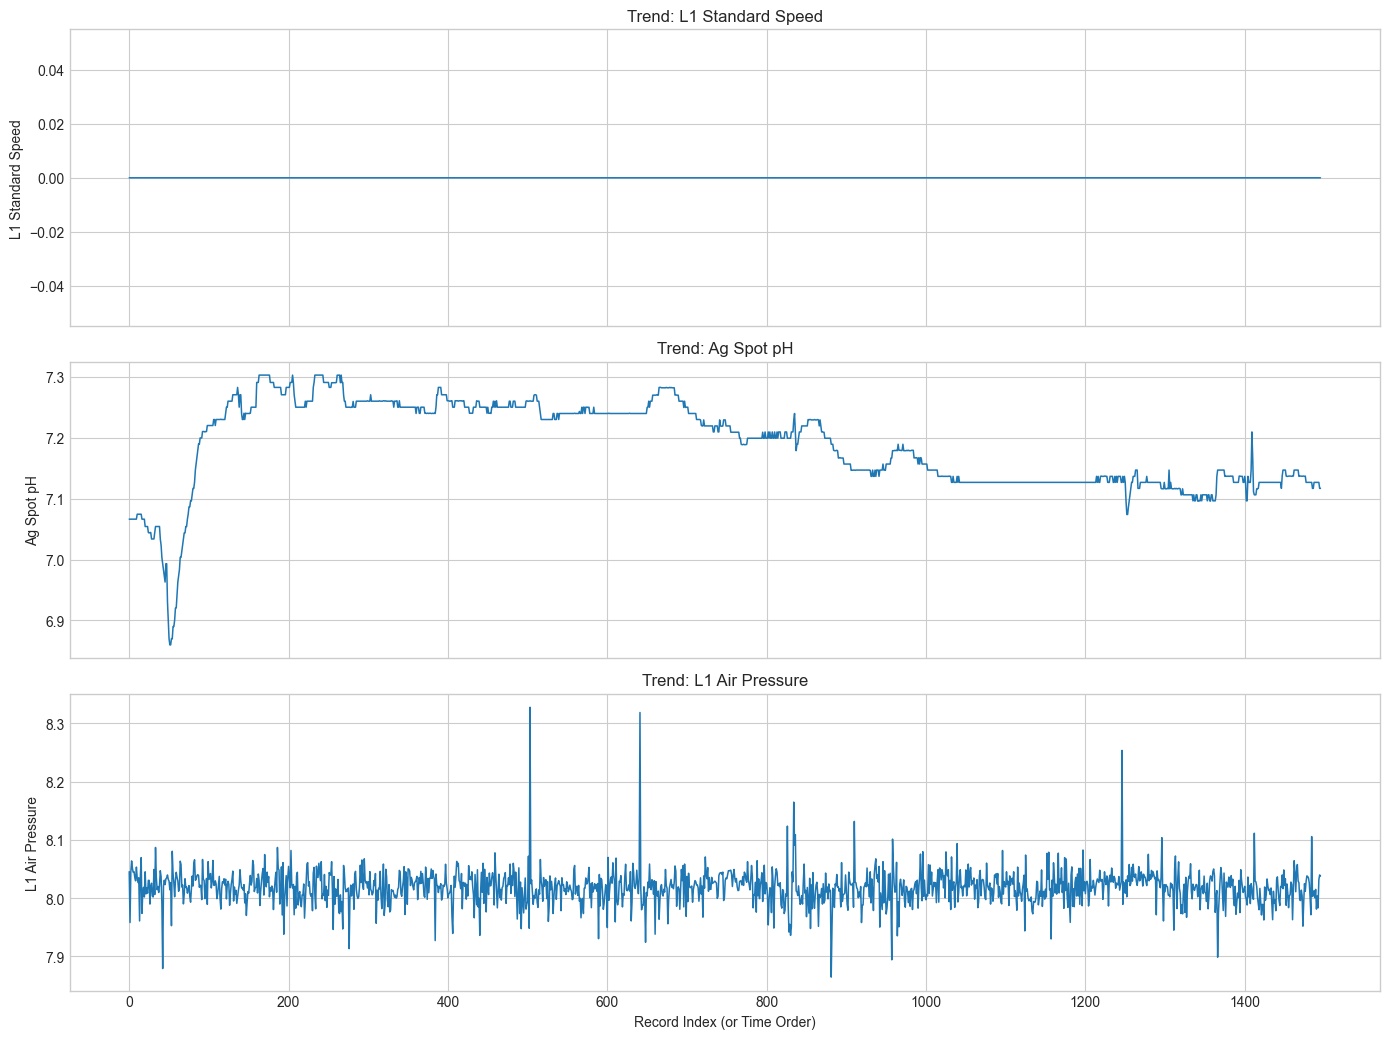

Detected columns:
{'speed': 'L1 Standard Speed', 'pH': 'Ag Spot pH', 'pressure': 'L1 Air Pressure'}


In [5]:
# 优先使用标准化后的线体快照做探索分析
eda_input = df_analysis if "df_analysis" in globals() else df_raw
key_map = plot_key_variables(eda_input)


## 3) 特征选择与清洗层（特征选择与清洗层）
原始日志可能有 ~173 列，但并非每一列都与过程稳定性高度相关。

这里我们做三件事：
1. 选出约 10 个高价值过程变量；
2. 列名标准化（下划线命名），降低跨项目维护成本；
3. 缺失值处理，得到稳定可用的 `df_clean`。

**前因后果**：
如果不先做 清洗层，后续异常检测结果会被脏数据放大，客户会质疑结论可信度。

In [6]:
def clean_data(df, selected_cols=None):
    # 中文说明：构建 df_clean（分析中间层）
    # 目标：让后续特征工程和异常检测都基于“可解释、可复用、可上线”的数据。
    df = df.copy()

    if selected_cols is None:
        # 中文说明：按制造场景常见重要变量做优先匹配
        priority_patterns = [
            ["speed"], ["ph"], ["pressure"], ["temp"], ["temperature"],
            ["flow"], ["current"], ["voltage"], ["torque"], ["vibration"], ["rpm"]
        ]

        selected_cols = []
        for p in priority_patterns:
            col = _find_column(df, p)
            if col and col not in selected_cols:
                selected_cols.append(col)
            if len(selected_cols) >= 10:
                break

    if not selected_cols:
        raise ValueError("未选中可用于清洗的列。")

    df_clean = df[selected_cols].copy()

    # 中文说明：字段标准化，避免中文/符号/空格导致脚本不稳定
    def normalize_col(c):
        c = c.strip().lower()
        c = re.sub(r"[^a-z0-9]+", "_", c)
        c = re.sub(r"_+", "_", c).strip("_")
        return c

    rename_map = {c: normalize_col(c) for c in df_clean.columns}
    df_clean = df_clean.rename(columns=rename_map)

    # 中文说明：尽量转为数值列，无法转换的记为 NaN
    for c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

    # 中文说明：缺失值处理策略
    # 1) ffill/bfill 保留时间连续性
    # 2) 若仍有缺失，用中位数兜底（抗异常值能力比均值更好）
    df_clean = df_clean.ffill().bfill()
    for c in df_clean.columns:
        if df_clean[c].isna().any():
            df_clean[c] = df_clean[c].fillna(df_clean[c].median())

    print(f"df_clean 数据形状： {df_clean.shape}")
    print("字段列表：", list(df_clean.columns))
    return df_clean

In [7]:
# 优先使用标准化后的线体快照进行后续分析；若不存在则回退原始宽表。
analysis_input = df_analysis if 'df_analysis' in globals() else df_raw
df_clean = clean_data(analysis_input)
display(df_clean.head())


df_clean shape: (1496, 6)
Columns: ['l1_standard_speed', 'ag_spot_ph', 'l1_air_pressure', 'l1_air_flow', 'l1_ed_1_current', 'l1_ed_1_voltage']


,l1_standard_speed,ag_spot_ph,l1_air_pressure,l1_air_flow,l1_ed_1_current,l1_ed_1_voltage
0,0,7.066441,8.045488,0.0,0,0.0
1,0,7.066441,7.958085,0.0,0,0.0
2,0,7.066441,8.044674,0.0,0,0.0
3,0,7.066441,8.063880,0.0,0,0.0
4,0,7.066441,8.051184,0.0,0,0.0


## 4) 特征工程（特征工程）
我们把原始点位转换成“更接近工艺行为”的特征：

- `speed_diff`：速度变化强度（识别节拍波动）；
- `pH_range`：滚动窗口内 pH 振幅（识别化学稳定性风险）；
- `pressure_variation`：滚动压力波动（识别设备/工艺应力波动）。

**业务意义**：
客户真正关心的是“过程是否稳定”，不是单个点位瞬时值本身。

In [8]:
# ===== 中文注释：以下代码可直接用于客户演示，强调“可解释、可落地、可复用” =====
def engineer_features(df_clean):
    df_feat = df_clean.copy()

    speed_col = _find_column(df_feat, ["speed"]) or _find_column(df_feat, ["rpm"])
    ph_col = _find_column(df_feat, ["ph"])
    pressure_col = _find_column(df_feat, ["pressure"])

    if speed_col is None:
        raise ValueError("未找到可用于 speed_diff 的速度类字段。")
    if ph_col is None:
        raise ValueError("未找到可用于 pH_range 的 pH 字段。")
    if pressure_col is None:
        raise ValueError("未找到可用于 pressure_variation 的压力字段。")

    df_feat["speed_diff"] = df_feat[speed_col].diff().abs().fillna(0)

    roll_window = 12
    ph_roll_max = df_feat[ph_col].rolling(roll_window, min_periods=1).max()
    ph_roll_min = df_feat[ph_col].rolling(roll_window, min_periods=1).min()
    df_feat["pH_range"] = ph_roll_max - ph_roll_min

    df_feat["pressure_variation"] = (
        df_feat[pressure_col].rolling(roll_window, min_periods=2).std().fillna(0)
    )

    return df_feat

In [9]:
df_feat = engineer_features(df_clean)
display(df_feat[["speed_diff", "pH_range", "pressure_variation"]].head(15))

,speed_diff,pH_range,pressure_variation
0,0.0,0.00000,0.000000
1,0.0,0.00000,0.061803
2,0.0,0.00000,0.050229
3,0.0,0.00000,0.047467
4,0.0,0.00000,0.042391
5,0.0,0.00000,0.038215
6,0.0,0.00000,0.035127
7,0.0,0.00000,0.032522
8,0.0,0.00000,0.030496
9,0.0,0.00000,0.029306


## 5) 异常检测（异常检测）
在没有良率标签时，我们先识别“异常工况时段”。

方法：
- 对每个数值特征做 Z分数；
- 聚合为 `anomaly_score`；
- 用分位数阈值得到 `anomaly_flag`。

**对客户的解释话术**：
这不是替代 SPC 规则，而是提供一层“无监督 AI 雷达”，帮助快速定位需要优先排查的时间段。

In [10]:
# ===== 中文注释：以下代码可直接用于客户演示，强调“可解释、可落地、可复用” =====
def detect_anomaly(df_feat, threshold_quantile=0.97):
    df_out = df_feat.copy()
    num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

    z_dict = {}
    for c in num_cols:
        mean = df_out[c].mean()
        std = df_out[c].std(ddof=0)
        if std == 0 or np.isnan(std):
            z_dict[c] = np.zeros(len(df_out))
        else:
            z_dict[c] = (df_out[c] - mean) / std

    z_df = pd.DataFrame(z_dict, index=df_out.index)
    df_out["anomaly_score"] = z_df.abs().mean(axis=1)

    cutoff = df_out["anomaly_score"].quantile(threshold_quantile)
    df_out["anomaly_flag"] = (df_out["anomaly_score"] >= cutoff).astype(int)

    print(f"异常阈值（分位数 q={threshold_quantile:.2f}）：{cutoff:.3f}")
    print(df_out["anomaly_flag"].value_counts().rename({0: "正常", 1: "AB正常"}))
    return df_out

Anomaly cutoff (q=0.97): 1.444
anomaly_flag
NORMAL      1451
ABNORMAL      45
Name: count, dtype: int64


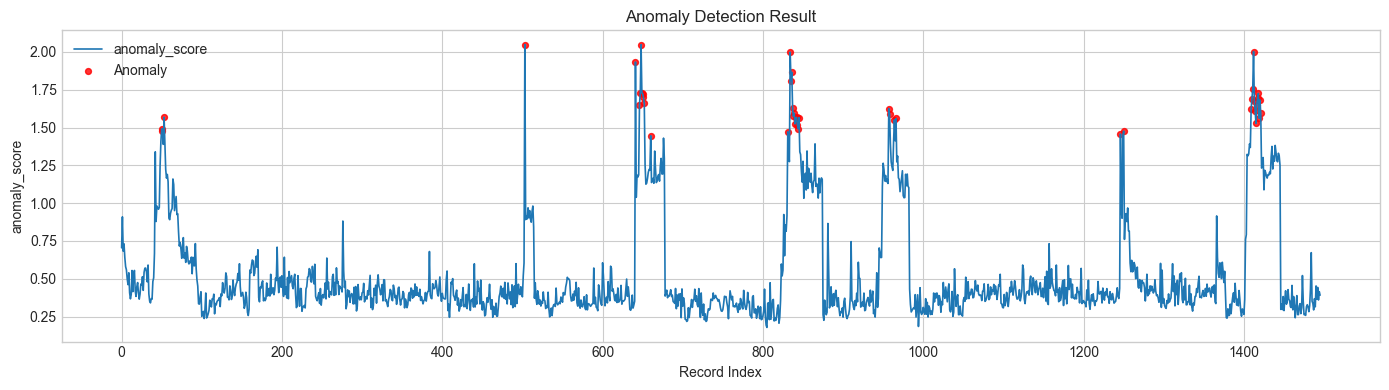

In [11]:
df_anom = detect_anomaly(df_feat, threshold_quantile=0.97)

def plot_anomalies(df, y_col="anomaly_score"):
    # 中文说明：绘制异常分数，并高亮异常段，便于快速定位风险时段
    plt.figure(figsize=(14, 4))
    plt.plot(df.index, df[y_col], label=cn_label(y_col), linewidth=1.2)

    abnormal_idx = df.index[df["anomaly_flag"] == 1]
    plt.scatter(abnormal_idx, df.loc[abnormal_idx, y_col], color="red", s=18, label="异常点", alpha=0.8)
    plt.title("异常检测结果")
    plt.xlabel("记录序号")
    plt.ylabel(cn_label(y_col))
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_anomalies(df_anom)


## 6) 分段对比（核心洞察）
将数据分为两段：
- 正常段
- 异常段

然后对比均值并按差异排序，得到“最值得关注的变量”。

**为什么这一步接近良率分析？**
虽然没有直接良率标签，但异常段常常对应过程偏离。比较两段差异，可以近似识别“潜在影响良率”的工艺因子。


In [12]:
# ===== 中文注释：以下代码可直接用于客户演示，强调“可解释、可落地、可复用” =====
def compare_segments(df_anom, top_n=10):
    num_cols = df_anom.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ["anomaly_flag"]]

    grp = df_anom.groupby("anomaly_flag")[num_cols].mean().T
    grp.columns = ["normal_mean", "abnormal_mean"]

    # 中文说明：增加中文展示字段，便于客户会上直接阅读

    grp["abs_diff"] = (grp["abnormal_mean"] - grp["normal_mean"]).abs()
    grp["pct_diff_vs_normal"] = np.where(
        grp["normal_mean"].abs() > 1e-12,
        (grp["abnormal_mean"] - grp["normal_mean"]) / grp["normal_mean"] * 100,
        np.nan,
    )

    ranked = grp.sort_values("abs_diff", ascending=False)
    ranked_display = ranked.rename(index=lambda x: cn_label(x), columns=lambda x: cn_label(x))
    return ranked_display.head(top_n), ranked_display

In [13]:
top_diff, full_diff = compare_segments(df_anom, top_n=10)
print("正常段与异常段差异最大的变量（Top10）：")
display(top_diff)


Top differences between NORMAL and ABNORMAL segments:


,normal_mean,abnormal_mean,abs_diff,pct_diff_vs_normal
l1_air_flow,155.709490,1513.690033,1357.980543,872.124455
l1_ed_1_current,2.377671,26.000000,23.622329,993.507246
l1_ed_1_voltage,0.937037,10.156444,9.219408,983.889919
anomaly_score,0.483689,1.654001,1.170312,241.955208
pH_range,0.016466,0.060006,0.043540,264.423779
pressure_variation,0.025295,0.057739,0.032444,128.264199
ag_spot_ph,7.188002,7.165080,0.022922,-0.318893
l1_air_pressure,8.018529,8.027219,0.008689,0.108365
l1_standard_speed,0.000000,0.000000,0.000000,NaN
speed_diff,0.000000,0.000000,0.000000,NaN


## 7) AI 文本洞察生成
我们把统计差异自动转成现场可读的结论：
- 哪些变量变化最大；
- 变化方向是什么；
- 建议先做哪些工程检查。

可选：调用本地 Ollama 生成更自然的中文客户报告文案。


In [17]:
# ===== 中文注释：以下代码可直接用于客户演示，强调“可解释、可落地、可复用” =====
def generate_insight(top_diff, max_items=5):
    # 中文说明：将差异结果转成可直接口播的洞察文本
    lines = []
    lines.append("AI洞察总结（正常 vs 异常）")
    lines.append("-" * 50)

    focus = top_diff.head(max_items).reset_index().rename(columns={"index": "feature"})
    for i, row in focus.iterrows():
        direction = "更高" if row["异常段均值"] > row["正常段均值"] else "更低"
        lines.append(
            f"{i+1}. {row['feature']}：异常段相对正常段{direction} "
            f"（正常={row['正常段均值']:.3f}，异常={row['异常段均值']:.3f}，"
            f"变化={row['相对正常段变化(%)']:.1f}%）。"
        )

    lines.append("\n建议优先检查：")
    lines.append("- 核对高差异变量的控制界限与设定值漂移。")
    lines.append("- 将异常时段与维保记录、换批/换线事件进行交叉比对。")
    lines.append("- 将这些变量作为根因分析与DOE实验设计的优先因子。")
    return "\n".join(lines)


def generate_insight_with_ollama(prompt, model="gemma4:e4b", url="http://localhost:11434/api/generate"):
    """
    可选能力：调用本地 Ollama 模型，生成更自然的客户汇报文案。
    需要先执行 `ollama serve` 并提前拉取模型。
    """
    import requests

    payload = {"model": model, "prompt": prompt, "stream": False}
    resp = requests.post(url, json=payload, timeout=150)
    resp.raise_for_status()
    return resp.json().get("response", "")


In [ ]:

# ===== 基础规则洞察 =====
insight_text = generate_insight(top_diff, max_items=5)

print("\n=== 规则生成洞察 ===")
print(insight_text)


# ===== AI增强洞察（自动fallback） =====
def safe_llm_insight(insight_text):
    # 中文说明：如本地LLM不可用，自动回退到规则洞察，保证演示不断档
    try:
        llm_prompt = f"""
你是一名制造工艺专家。

请将下面的分析结果整理为简洁、专业、适合客户汇报的中文洞察。
重点覆盖：
- 关键异常因子
- 可能的工艺影响
- 建议优先关注方向

分析内容：
{insight_text}
"""
        ai_text = generate_insight_with_ollama(
            llm_prompt,
            model="gemma4:e4b"  # 或你实际模型
        )
        return ai_text.strip()

    except Exception as e:
        return f"[LLM不可用] 已回退为规则洞察。\n错误信息：{str(e)}"


# ===== 输出AI洞察 =====
print("\n=== AI洞察（LLM增强）===")
ai_insight = safe_llm_insight(insight_text)
print(ai_insight)

print("\n" + "="*50)
print("最终洞察对比")
print("="*50)

print("\n[1] 规则生成洞察：\n")
print(insight_text)

print("\n[2] AI增强洞察：\n")
print(ai_insight)



=== Rule-based Insight ===
AI Insight Summary (Normal vs Abnormal)
--------------------------------------------------
1. l1_air_flow: abnormal is higher than normal (normal=155.709, abnormal=1513.690, delta=872.1%).
2. l1_ed_1_current: abnormal is higher than normal (normal=2.378, abnormal=26.000, delta=993.5%).
3. l1_ed_1_voltage: abnormal is higher than normal (normal=0.937, abnormal=10.156, delta=983.9%).
4. anomaly_score: abnormal is higher than normal (normal=0.484, abnormal=1.654, delta=242.0%).
5. pH_range: abnormal is higher than normal (normal=0.016, abnormal=0.060, delta=264.4%).

Recommended next checks:
- Verify control limits and setpoint drift on top-shifted variables.
- Cross-check abnormal windows with maintenance / lot change events.
- Use these variables as priority candidates for root-cause and DOE planning.

=== AI Insight (LLM Enhanced) ===


## 8) 最终结论（给管理层）
- 这套方法可补足 MES 分析中的一部分“早期诊断”能力；
- 不需要良率标签也能先做过程风险定位；
- 适合快速 PoC，再逐步接入更多系统（MES/QMS/维保事件）。

**落地收益**：
上线快、投入轻、见效早，适合中国制造客户先小步试点再规模复制。


## 9) 演示讲解要点（客户演示讲稿）
1. **先解决 80% 的问题，再谈大平台**：不用等 MES 全部打通，先从设备日志直接产出洞察。  
2. **没有良率标签也能做**：通过异常段对比，先找出高风险变量，提升排查效率。  
3. **结果可解释，工程师听得懂**：趋势图 + 差异表 + 中文洞察建议。  
4. **技术栈轻量，信息化 阻力小**：pandas/numpy/matplotlib 即可启动。  
5. **可平滑升级**：后续接入良率、批次、维保记录后，模型效果会持续增强。

---

### 总结
> 我们这套方法不是替代 MES，而是让您在 MES 完整建设前，就先拿到可行动的工艺洞察。  
> 先快速看到异常、定位重点变量、缩小排查范围，再决定下一步系统化投资，风险更低、回报更快。

## 本演示价值总结
- **没有MES也能发现问题**：直接利用设备日志做数据清洗、异常识别与分段对比，快速定位疑似风险工况。
- **AI辅助工程师提效**：先用规则洞察确保稳定输出，再用LLM生成客户可读总结，减少手工整理时间。
- **后续可扩展方向**：逐步接入良率、批次、维保与换线事件；从“发现异常”升级到“预测风险与闭环优化”。


本 Notebook 已将原始设备宽表日志标准化为线体快照、公共设备快照和指标长表。该结构不再依赖固定列号，能够兼容一机两线、一机三线或更多线体，并能自动识别重复字段、线体字段不一致和公共设备参数，为后续良率分析、异常检测和 AI 洞察提供可靠的数据基础。
